In [ ]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# Statistics analyses inter-regions

In this notebook you'll find everything to compute descriptive statistics for our paper on concept cells in the human declarative memory system

## Responsiveness

In [2]:
# In the temporal pole
import numpy as np

path2data = 'C:/Users/dornier/GitHub/ConceptCells_DecMem/'
nb_response_neuron_tp = np.load(path2data+'data/Responsiveness/Percentage_Response_TP.npy')

mean_response_tp = np.mean(nb_response_neuron_tp)
median_response_tp = np.median(nb_response_neuron_tp)
std_response_tp = np.std(nb_response_neuron_tp)

print('Les neurones dans TP répondent en moyenne à '+str(mean_response_tp)+' images (+- '+str(std_response_tp)+')')
print('\nAvec pour médiane: '+str(median_response_tp))

Les neurones dans TP répondent en moyenne à 0.07424245676178763 images (+- 0.06881815796491099)

Avec pour médiane: 0.05357142857142857


In [3]:
# In the PCC
import numpy as np

nb_response_neuron_pcc = np.load(path2data+'data/Responsiveness/Percentage_Response_PCC.npy')

mean_response_pcc = np.mean(nb_response_neuron_pcc)
median_response_pcc = np.median(nb_response_neuron_pcc)
std_response_pcc = np.std(nb_response_neuron_pcc)

print('Les neurones dans PCC répondent en moyenne à '+str(mean_response_pcc)+' images (+- '+str(std_response_pcc)+')')
print('\nAvec pour médiane: '+str(median_response_pcc))

Les neurones dans PCC répondent en moyenne à 0.07912127002831089 images (+- 0.05294161679697913)

Avec pour médiane: 0.07142857142857142


In [4]:
# Statistical testing
res = stats.mannwhitneyu(nb_response_neuron_tp,nb_response_neuron_pcc)

print('Difference between TP and PCC: t= '+str(res.statistic)+',p='+str(res.pvalue))

Difference between TP and PCC: t= 6863.0,p=0.019059793965275927


## Spiking variability - Permutation entropy

In the following section we will analyze the result for the permutation entropy analysis (Extended Data Fig. 7a, b)



In [5]:
# Import all data
path_pe = path2data+'data/Spiking_Variability/'


# Load permutation entropy data
pe_tp = np.load(path_pe+'Permutation_Entropy_TP.npy')
pe_hipp = np.load(path_pe+'Permutation_Entropy_Hippocampus.npy')
pe_gph = np.load(path_pe+'Permutation_Entropy_Parahippocampal.npy')
pe_pcc = np.load(path_pe+'Permutation_Entropy_PCC.npy')


# Suppress nan values
pe_tp = pe_tp[~np.isnan(pe_tp)]
pe_hipp = pe_hipp[~np.isnan(pe_hipp)]
pe_gph = pe_gph[~np.isnan(pe_gph)]
pe_pcc = pe_pcc[~np.isnan(pe_pcc)]


In [6]:
# Descriptive statistics

# Mean
mean_pe_tp = np.mean(pe_tp)
mean_pe_gph = np.mean(pe_gph)
mean_pe_hippocampus = np.mean(pe_hipp)
mean_pe_pcc = np.mean(pe_pcc)


# Standard deviation
std_pe_tp = np.std(pe_tp)
std_pe_gph = np.std(pe_gph)
std_pe_hippocampus = np.std(pe_hipp)
std_pe_pcc = np.std(pe_pcc)


# Print results
print('Permutation entropy - descriptive statistics')
print('\nTemporal pole: mean = '+str(mean_pe_tp)+' (std = '+ str(std_pe_tp)+')')
print('\nParahippocampal: mean = '+str(mean_pe_gph)+' (std = '+ str(std_pe_gph)+')')
print('\nHippocampus: mean = '+str(mean_pe_hippocampus)+' (std = '+ str(std_pe_hippocampus)+')')
print('\nPCC: mean = '+str(mean_pe_pcc)+' (std = '+ str(std_pe_pcc)+')')





Permutation entropy - descriptive statistics

Temporal pole: mean = 0.09597018125035281 (std = 0.06675695837025812)

Parahippocampal: mean = 0.1309198110366018 (std = 0.10546561696641854)

Hippocampus: mean = 0.1343893244584598 (std = 0.0996881771278004)

PCC: mean = 0.1614433185838718 (std = 0.11285136916644856)


Kruskal-wallis: H = 57.934713233282444, p = 1.6231458138599316e-12


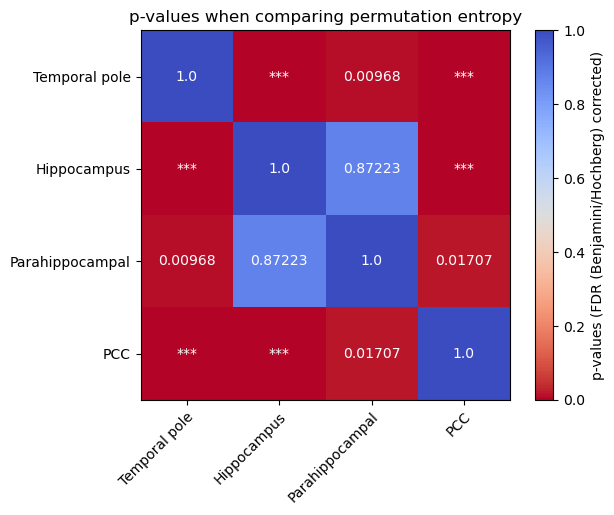

In [10]:
# Statistical test

# First assess if difference between one group with Kruskal-Wallis
res_kruskal = stats.kruskal(pe_tp, pe_hipp, pe_gph,pe_pcc)

print('Kruskal-wallis: H = '+str(res_kruskal.statistic)+', p = '+str(res_kruskal.pvalue))


import scikit_posthocs as posthoc

# posthoc dunn test, with correction for multiple testing
dunn_df = posthoc.posthoc_dunn(
    [pe_tp,pe_hipp,pe_gph,pe_pcc], p_adjust='fdr_bh'
)



fig, ax = plt.subplots()

p_values = np.round(np.array(dunn_df),5)
im = ax.imshow(p_values,cmap='coolwarm_r')

fig.colorbar(im,ax=ax, label='p-values (FDR (Benjamini/Hochberg) corrected)')

roi = ['Temporal pole','Hippocampus','Parahippocampal','PCC']

# Show all ticks and label them with the respective list entries
ax.set_xticks(range(len(roi)), labels=roi,
              rotation=45, ha="right", rotation_mode="anchor")
ax.set_yticks(range(len(roi)), labels=roi)

# Loop over data dimensions and create text annotations.
for i in range(len(roi)):
    for j in range(len(roi)):

        if p_values[i,j] < 0.0005:
            text = ax.text(j, i, '***',
                       ha="center", va="center", color="w")
        else:
            text = ax.text(j, i, p_values[i,j],
                       ha="center", va="center", color="w")

ax.set_title("p-values when comparing permutation entropy")

plt.savefig(path_pe+'/Heatmap_pvalues_PermutationEntropy.svg')
plt.show()

In [11]:
# Show exact values
dunn_df

,1,2,3,4
1,1.000000e+00,0.000132,0.009684,4.321941e-13
2,1.324225e-04,1.000000,0.872233,3.191096e-04
3,9.683519e-03,0.872233,1.000000,1.707459e-02
4,4.321941e-13,0.000319,0.017075,1.000000e+00


# Onset latencies

Analyze the different onset latencies (Fig. 5b)

In [12]:
path_latency = path2data+'data/Latency/'

# Load the latencies of each region
onset_tp = np.load(path_latency+'Latency_TP.npy')
onset_gph = np.load(path_latency+'Latency_Parahippocampal.npy')
onset_hipp = np.load(path_latency+'Latency_Hippocampus.npy')
onset_pcc = np.load(path_latency+'Latency_PCC.npy')
onset_amygdala = np.load(path_latency+'Latency_Amygdala.npy')

In [13]:
# Get the descriptive statistics for each region


# Compute the mean across all brain areas
mean_tp = np.mean(onset_tp)
mean_gph = np.mean(onset_gph)
mean_hipp = np.mean(onset_hipp)
mean_pcc = np.mean(onset_pcc)
mean_amygdala = np.mean(onset_amygdala)

# Get the standard deviation across all brain areas
sd_tp = np.std(onset_tp)
sd_gph = np.std(onset_gph)
sd_hipp = np.std(onset_hipp)
sd_pcc = np.std(onset_pcc)
sd_amygdala = np.std(onset_amygdala)


# Print the descriptive statistics
print('Onset TP : M = '+str(mean_tp)+' (+- '+str(sd_tp)+')')
print('\nOnset GPH : M = '+str(mean_gph)+' (+- '+str(sd_gph)+')')
print('\nOnset Hippocampus : M = '+str(mean_hipp)+' (+- '+str(sd_hipp)+')')
print('\nOnset PCC : M = '+str(mean_pcc)+' (+- '+str(sd_pcc)+')')
print('\nOnset Amygdala : M = '+str(mean_amygdala)+' (+- '+str(sd_amygdala)+')')


Onset TP : M = 379.9079363924457 (+- 210.59155431073276)

Onset GPH : M = 193.79803138076315 (+- 149.44811073172548)

Onset Hippocampus : M = 426.94342704221344 (+- 190.2151265641582)

Onset PCC : M = 488.7164196174197 (+- 147.07128989703645)

Onset Amygdala : M = 449.0368838763576 (+- 177.9602261079125)


In [14]:
# Statistical test
import scipy.stats as stats

# First assess if difference between one group with Kruskal-Wallis
res_kruskal = stats.kruskal(onset_tp, onset_hipp, onset_gph, onset_pcc, onset_amygdala)

print('Kruskal-wallis: H = '+str(res_kruskal.statistic)+', p = '+str(res_kruskal.pvalue))


import scikit_posthocs as posthoc

# posthoc dunn test, with correction for multiple testing
dunn_df = posthoc.posthoc_mannwhitney(
    [onset_tp, onset_hipp, onset_gph, onset_pcc, onset_amygdala],p_adjust='fdr_bh'
)
dunn_df

Kruskal-wallis: H = 77.30628355055092, p = 6.477857968386488e-16


,1,2,3,4,5
1,1.000000e+00,6.381281e-02,3.495488e-07,1.484678e-04,1.033274e-02
2,6.381281e-02,1.000000e+00,4.993715e-11,7.350676e-03,2.326400e-01
3,3.495488e-07,4.993715e-11,1.000000e+00,1.208436e-13,4.274736e-11
4,1.484678e-04,7.350676e-03,1.208436e-13,1.000000e+00,2.113234e-01
5,1.033274e-02,2.326400e-01,4.274736e-11,2.113234e-01,1.000000e+00


# Selectivity measures

Here we compute statistical testing on selectivity of all regions (Fig. 5e)

In [15]:
path_selectivity = path2data+'data/Selectivity/'

# Load the latencies of each region
selectivity_tp = np.load(path_selectivity+'selectivity_tp.npy')
selectivity_gph = np.load(path_selectivity+'selectivity_parahippocampal.npy')
selectivity_hipp = np.load(path_selectivity+'selectivity_hippocampus.npy')
selectivity_pcc = np.load(path_selectivity+'selectivity_pcc.npy')
selectivity_amygdala = np.load(path_selectivity+'selectivity_amygdala.npy')

In [16]:
# Get the descriptive statistics for each region


# Compute the mean across all brain areas
mean_tp = np.mean(selectivity_tp)
mean_gph = np.mean(selectivity_gph)
mean_hipp = np.mean(selectivity_hipp)
mean_pcc = np.mean(selectivity_pcc)
mean_amygdala = np.mean(selectivity_amygdala)

# Get the standard deviation across all brain areas
sd_tp = np.std(selectivity_tp)
sd_gph = np.std(selectivity_gph)
sd_hipp = np.std(selectivity_hipp)
sd_pcc = np.std(selectivity_pcc)
sd_amygdala = np.std(selectivity_amygdala)


# Print the descriptive statistics
print('Selectivity TP : M = '+str(mean_tp)+' (+- '+str(sd_tp)+')')
print('\nSelectivity GPH : M = '+str(mean_gph)+' (+- '+str(sd_gph)+')')
print('\nSelectivity Hippocampus : M = '+str(mean_hipp)+' (+- '+str(sd_hipp)+')')
print('\nSelectivity PCC : M = '+str(mean_pcc)+' (+- '+str(sd_pcc)+')')
print('\nSelectivity Amygdala : M = '+str(mean_amygdala)+' (+- '+str(sd_amygdala)+')')

Selectivity TP : M = 0.46907500801424534 (+- 0.19464845848049225)

Selectivity GPH : M = 0.5395985687890593 (+- 0.22049329767371012)

Selectivity Hippocampus : M = 0.3965218806306783 (+- 0.23945511570405792)

Selectivity PCC : M = 0.3280214514798867 (+- 0.17274133769240108)

Selectivity Amygdala : M = 0.3324566677804779 (+- 0.20042088118606097)


In [17]:
# Statistical test
import scipy.stats as stats

# First assess if difference between one group with Kruskal-Wallis
res_kruskal = stats.kruskal(selectivity_tp, selectivity_hipp, selectivity_gph, selectivity_pcc, selectivity_amygdala)

print('Kruskal-wallis: H = '+str(res_kruskal.statistic)+', p = '+str(res_kruskal.pvalue))


import scikit_posthocs as posthoc

# posthoc dunn test, with correction for multiple testing
dunn_df = posthoc.posthoc_mannwhitney(
    [selectivity_tp, selectivity_hipp, selectivity_gph, selectivity_pcc, selectivity_amygdala],p_adjust='fdr_bh'
)
dunn_df

Kruskal-wallis: H = 41.01244142324845, p = 2.6719332151627546e-08


,1,2,3,4,5
1,1.000000,0.018085,0.099704,0.000030,0.000030
2,0.018085,1.000000,0.002996,0.188949,0.099704
3,0.099704,0.002996,1.000000,0.000030,0.000041
4,0.000030,0.188949,0.000030,1.000000,0.644697
5,0.000030,0.099704,0.000041,0.644697,1.000000
